<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>
<center><b><h1>KAVATHIYA KHUSHI | 23010101137</b></center>       
<center><b><h1>Task - 1</b></center>    
<pre>    

## Problem Statement
- Predict whether a person has heart disease based on medical and lifestyle data.  
- Clean the dataset and find which features affect heart health.  
- Prepare the data for ML or statistical analysis.

## Dataset Summary
- **age** – patient age  
- **gender** – 1 = male, 2 = female  
- **height** – in cm  
- **weight** – in kg  
- **ap_hi** – systolic blood pressure  
- **ap_lo** – diastolic blood pressure  
- **cholesterol** – 1/2/3 levels  
- **gluc** – glucose level (1/2/3)  
- **smoke** – 0/1  
- **alco** – alcohol intake 0/1  
- **active** – physically active 0/1  
- **cardio** – target variable (1 = disease, 0 = no disease)

## Initial Observations
- BP values contain unrealistic numbers → needs fixing.  
- Height/weight show impossible values → must be clipped.  
- Categorical columns are numeric → need interpretation.  
- Target variable may be imbalanced.  
- Features like BP, cholesterol, glucose may show correlations.

### Read CSV File:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv("cardio_train.csv",sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [6]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [7]:
df.tail(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69990,99986,15094,1,168,72.0,110,70,1,1,0,0,1,1
69991,99988,20609,1,159,72.0,130,90,2,2,0,0,1,0
69992,99990,18792,1,161,56.0,170,90,1,1,0,0,1,1
69993,99991,19699,1,172,70.0,130,90,1,1,0,0,1,1
69994,99992,21074,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


### chaeak if there is any null value in dataset

In [9]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### Getting the basic info about the dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### check shape

In [10]:
df.shape

(70000, 13)

### Columns Name

In [11]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

### check Datatypes

In [12]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

### Summary of Numerical Data

In [37]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Access rows by their integer locations

In [13]:
#iloc means integeer location and this is used for access rows and columns by their integer position.
df.iloc[0]

id                 0.0
age            18393.0
gender             2.0
height           168.0
weight            62.0
ap_hi            110.0
ap_lo             80.0
cholesterol        1.0
gluc               1.0
smoke              0.0
alco               0.0
active             1.0
cardio             0.0
Name: 0, dtype: float64

### Summary of categorical columns

In [14]:
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())
    print("-------------------------------")


Value counts for gender:
gender
1    45530
2    24470
Name: count, dtype: int64
-------------------------------

Value counts for cholesterol:
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64
-------------------------------

Value counts for gluc:
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64
-------------------------------

Value counts for smoke:
smoke
0    63831
1     6169
Name: count, dtype: int64
-------------------------------

Value counts for alco:
alco
0    66236
1     3764
Name: count, dtype: int64
-------------------------------

Value counts for active:
active
1    56261
0    13739
Name: count, dtype: int64
-------------------------------


### Correlation between all numeric columns

In [15]:
df.corr()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,1.000000,0.003457,0.003502,-0.003038,-0.001830,0.003356,-0.002529,0.006106,0.002467,-0.003699,0.001210,0.003755,0.003799
age,0.003457,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,0.003502,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.003038,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,-0.001830,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.003356,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,-0.002529,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.006106,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.002467,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.003699,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486


- ## Cardio

### Check the distribution of target value

In [17]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

### Visualization of target column

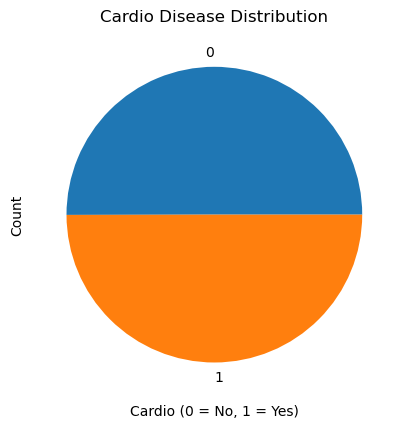

In [18]:
df['cardio'].value_counts().plot(kind='pie')
plt.title("Cardio Disease Distribution")
plt.xlabel("Cardio (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

- ## Age

In [19]:
df['age']=df['age']//365
df
# // integer aape

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


### Visual representation of age column

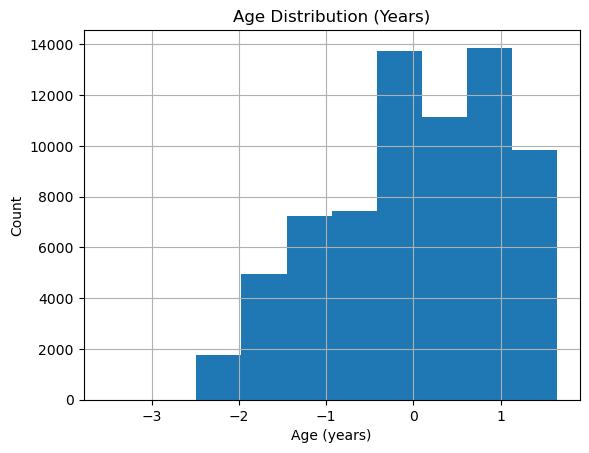

In [83]:
plt.figure()
df['age'].hist()
plt.title('Age Distribution (Years)')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

### Age Vs. Disease

In [21]:
df.groupby('cardio')['age'].mean() *100

cardio
0    5123.126124
1    5445.201407
Name: age, dtype: float64

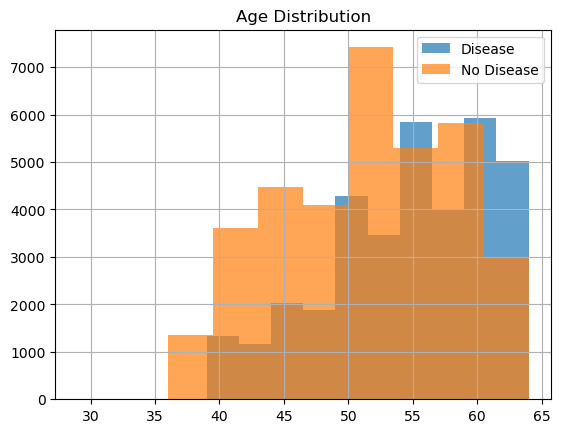

In [22]:
df[df['cardio']==1]['age'].hist(alpha=0.7)
df[df['cardio']==0]['age'].hist(alpha=0.7)
plt.legend(['Disease','No Disease'])
plt.title("Age Distribution")
plt.show()

### Gender Vs. Disease

In [23]:
pd.crosstab(df['gender'], df['cardio'])

cardio,0,1
gender,,
1,22914,22616
2,12107,12363


### Check whether male or female has higher cardio cases

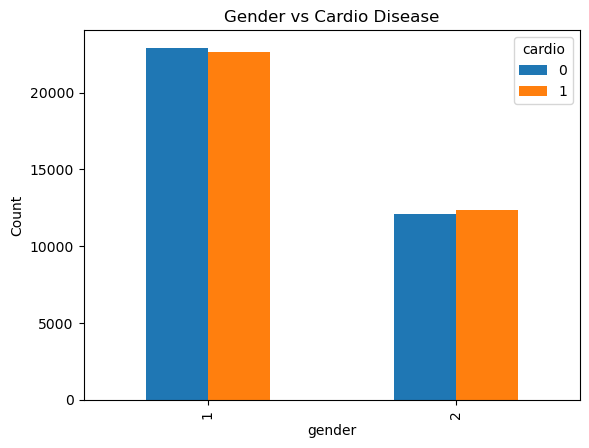

In [24]:
pd.crosstab(df['gender'], df['cardio']).plot(kind='bar')
plt.title("Gender vs Cardio Disease")
plt.ylabel('Count')
plt.show()

- ## Height

<Axes: >

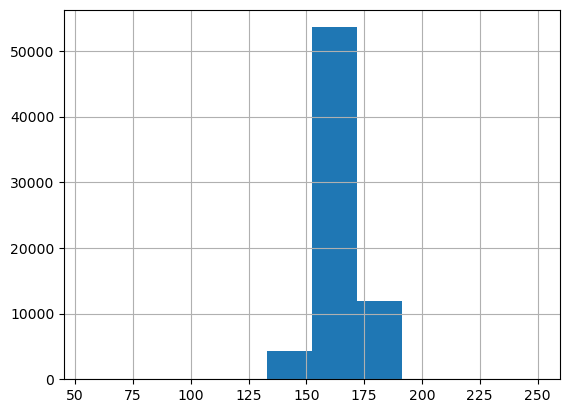

In [25]:
df['height'].hist()

In [26]:
#height can be much good if in fts and inches 
feet = (df['height'] / 30.48).astype(int) 
feet

0        5
1        5
2        5
3        5
4        5
        ..
69995    5
69996    5
69997    6
69998    5
69999    5
Name: height, Length: 70000, dtype: int32

In [27]:
inches = (((df['height'] / 30.48) - feet) * 12).astype(int)
inches

0        6
1        1
2        4
3        6
4        1
        ..
69995    6
69996    2
69997    0
69998    4
69999    6
Name: height, Length: 70000, dtype: int32

In [28]:
feet.astype(str) + "'" + inches.astype(str)+ '"'

0        5'6"
1        5'1"
2        5'4"
3        5'6"
4        5'1"
         ... 
69995    5'6"
69996    5'2"
69997    6'0"
69998    5'4"
69999    5'6"
Name: height, Length: 70000, dtype: object

- ## Weight

<Axes: >

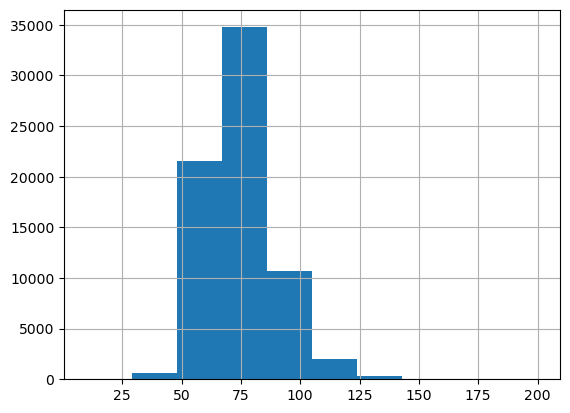

In [29]:
df['weight'].hist()

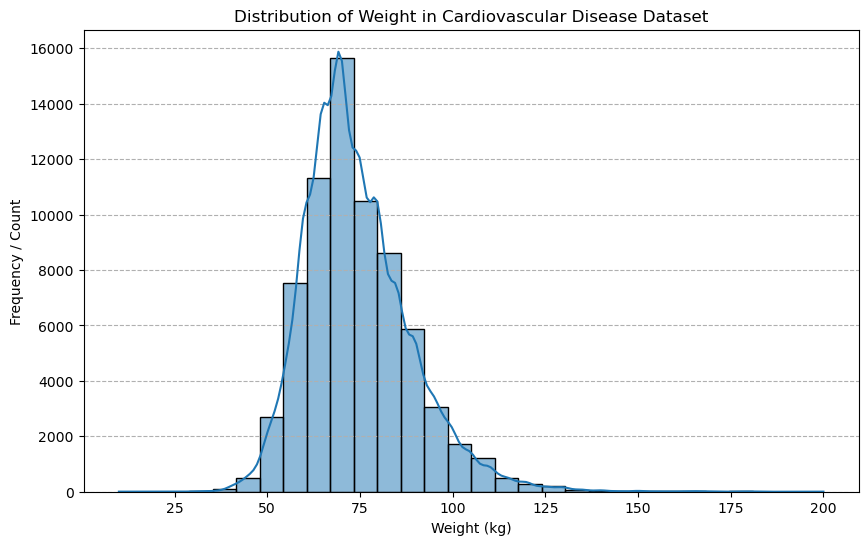

In [30]:
df1 = df[(df['weight'] > 30) & (df['weight'] < 150)] 
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(data=df, x='weight', kde=True, bins=30) # 'kde=True' adds a density line

plt.title('Distribution of Weight in Cardiovascular Disease Dataset')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency / Count')
plt.grid(True, axis='y', linestyle='--') # Add horizontal grid lines

plt.show()

- ## ap_hi & ap_lo

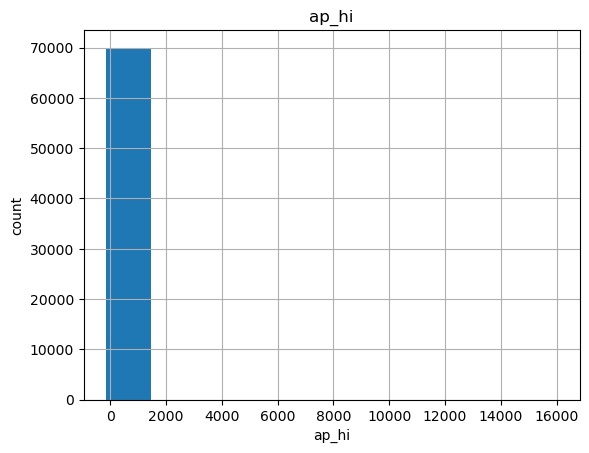

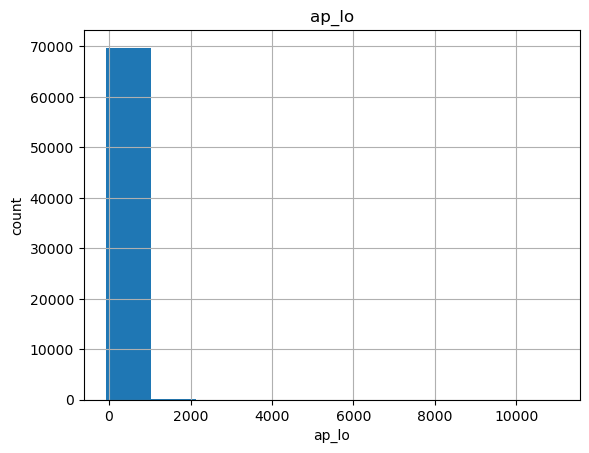

In [31]:
# histograms for ap_hi & ap_lo
bp = ['ap_hi','ap_lo']
for col in bp:
    plt.figure()
    df[col].hist()
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

In [32]:
# Fix obvious errors: ap_lo > ap_hi
df1 = df[df['ap_lo'] <= df['ap_hi']]
df1

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [33]:
max_ap_hi = df['ap_hi'].max()
min_ap_hi = df['ap_hi'].min()
distinct_ap_hi = df['ap_hi'].value_counts().sort_index()
print(f'Maximum Systolic BP: {max_ap_hi}')
print(f'Minimum Systolic BP: {min_ap_hi}')
print(distinct_ap_hi)

Maximum Systolic BP: 16020
Minimum Systolic BP: -150
ap_hi
-150      1
-140      1
-120      2
-115      1
-100      2
         ..
 11020    1
 11500    1
 13010    2
 14020    4
 16020    1
Name: count, Length: 153, dtype: int64


In [34]:
max_ap_lo = df['ap_lo'].max()
min_ap_lo = df['ap_lo'].min()
distinct_ap_lo = df['ap_lo'].value_counts().sort_index()
print(f'Maximum Diastolic BP: {max_ap_lo}')
print(f'Minimum Diastolic BP: {min_ap_lo}')
print(distinct_ap_lo)

Maximum Diastolic BP: 11000
Minimum Diastolic BP: -70
ap_lo
-70        1
 0        21
 1         1
 6         2
 7         2
          ..
 9011      2
 9100      1
 9800      1
 10000     3
 11000     1
Name: count, Length: 157, dtype: int64


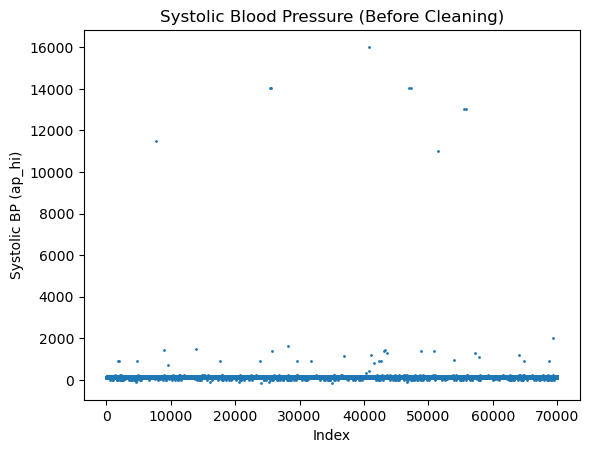

In [35]:
plt.figure()
plt.scatter(range(len(df)), df['ap_hi'], s=1)
plt.title("Systolic Blood Pressure (Before Cleaning)")
plt.xlabel("Index")
plt.ylabel("Systolic BP (ap_hi)")
plt.show()

In [36]:
cleaned = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]

In [37]:
cleaned = cleaned[
    (cleaned['ap_hi'] >= 70) & (cleaned['ap_hi'] <= 250) &
    (cleaned['ap_lo'] >= 40) & (cleaned['ap_lo'] <= 150)
]

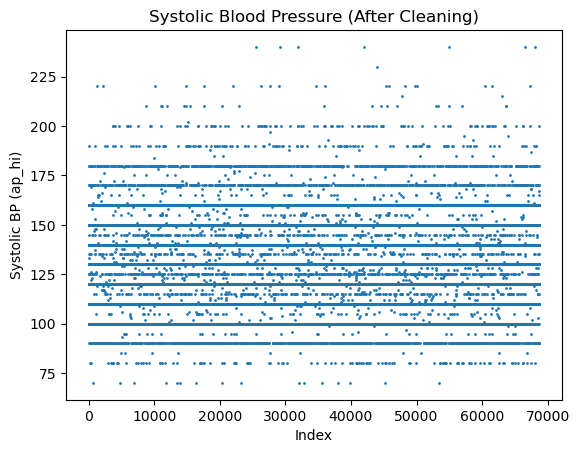

In [38]:
plt.figure()
plt.scatter(range(len(cleaned)), cleaned['ap_hi'], s=1)
plt.title("Systolic Blood Pressure (After Cleaning)")
plt.xlabel("Index")
plt.ylabel("Systolic BP (ap_hi)")
plt.show()

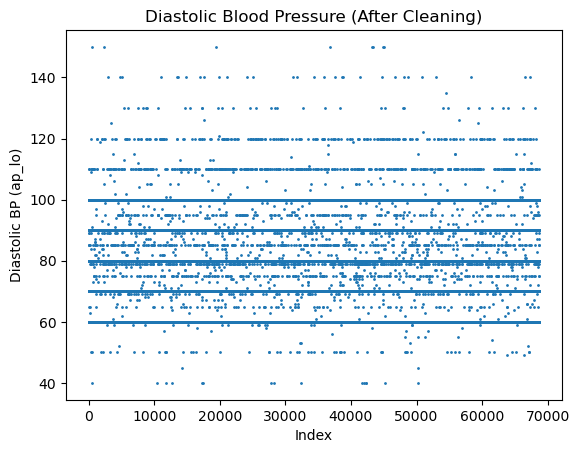

In [39]:
plt.figure()
plt.scatter(range(len(cleaned)), cleaned['ap_lo'], s=1)
plt.title("Diastolic Blood Pressure (After Cleaning)")
plt.xlabel("Index")
plt.ylabel("Diastolic BP (ap_lo)")
plt.show()

- ## Cholesterol [1: normal, 2: above normal, 3: well above normal]

In [40]:
df['cholesterol'].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

<Axes: xlabel='cholesterol'>

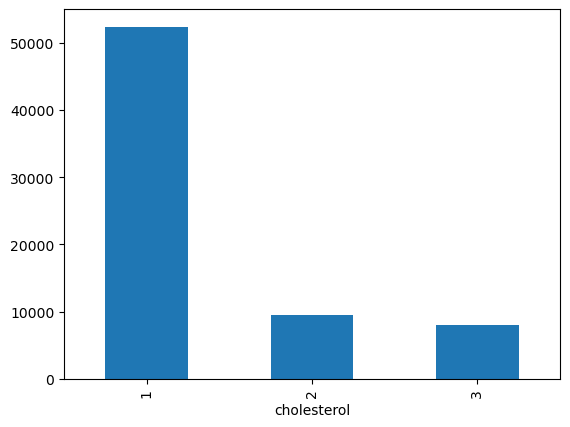

In [41]:
df['cholesterol'].value_counts().plot(kind='bar')

### Cholesterol Vs. Disease

In [42]:
pd.crosstab(df['cholesterol'], df['cardio'])

cardio,0,1
cholesterol,,
1,29330,23055
2,3799,5750
3,1892,6174


- ## Glucose [1: normal, 2: above normal, 3: well above normal]

In [43]:
df['gluc'].value_counts()

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64

In [44]:
df.groupby('gluc')['cardio'].mean() *100

gluc
1    48.058979
2    59.306358
3    62.202213
Name: cardio, dtype: float64

### Glucose Vs. Disease

In [45]:
pd.crosstab(df['gluc'], df['cardio'])

cardio,0,1
gluc,,
1,30894,28585
2,2112,3078
3,2015,3316


## #Smoke [0: Non Smoker, 1: Smoker]

In [46]:
df['smoke'].value_counts()

smoke
0    63831
1     6169
Name: count, dtype: int64

In [47]:
df.groupby('smoke')['cardio'].mean()

smoke
0    0.502107
1    0.474793
Name: cardio, dtype: float64

### Smoking Vs. Disease

In [48]:
pd.crosstab(df['smoke'], df['cardio'])

cardio,0,1
smoke,,
0,31781,32050
1,3240,2929


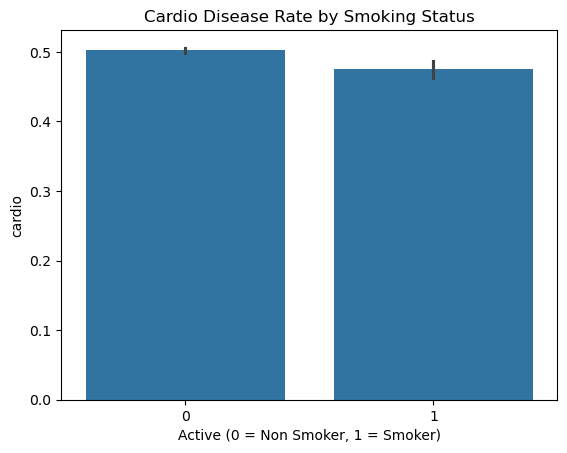

In [49]:
sns.barplot(data=df, x='smoke', y='cardio')
plt.title("Cardio Disease Rate by Smoking Status")
plt.xlabel("Active (0 = Non Smoker, 1 = Smoker)")
plt.show()

 - ## Alcohol [0: Non Alcoholic Peoples, 1: Alcoholic Peoples]

In [50]:
df['alco'].value_counts()

alco
0    66236
1     3764
Name: count, dtype: int64

In [51]:
# 0 -> for no alcoholic people 1 -> for alcoholic people
df.groupby('alco')['cardio'].mean()

alco
0    0.500574
1    0.484325
Name: cardio, dtype: float64

### Alcohol Vs. Disease

In [53]:
pd.crosstab(df['alco'], df['cardio'])

cardio,0,1
alco,,
0,33080,33156
1,1941,1823


- ## Physical Activity [0: NonActive, 1: Active]

In [54]:
df['active'].value_counts(normalize=True) #normalize will give percentage

active
1    0.803729
0    0.196271
Name: proportion, dtype: float64

In [55]:
df.groupby('active')['cardio'].mean()

active
0    0.535774
1    0.490891
Name: cardio, dtype: float64

### Physicaly Active Vs. Disease

In [56]:
pd.crosstab(df['active'], df['cardio'])

cardio,0,1
active,,
0,6378,7361
1,28643,27618


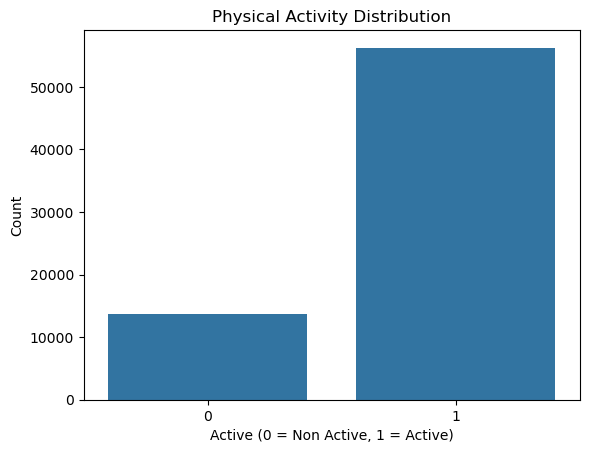

In [57]:
#for counting purpose countplot are used
sns.countplot(data=df, x='active')
plt.title("Physical Activity Distribution")
plt.xlabel("Active (0 = Non Active, 1 = Active)")
plt.ylabel("Count")
plt.show()

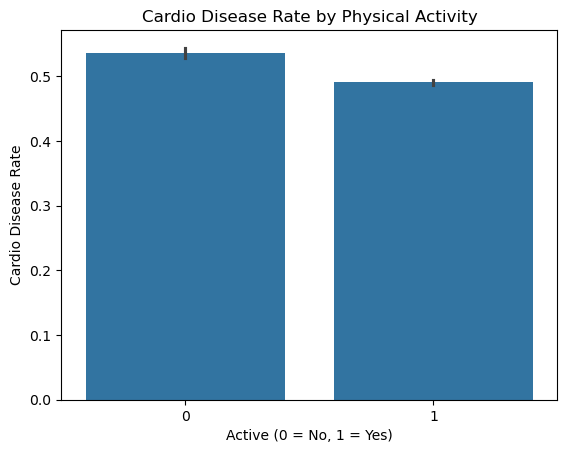

In [58]:
#cadio vs physical activity
sns.barplot(data=df, x='active', y='cardio')
plt.title("Cardio Disease Rate by Physical Activity")
plt.xlabel("Active (0 = No, 1 = Yes)")
plt.ylabel("Cardio Disease Rate")
plt.show()

In [ ]:
# Categorical encoding: one-hot or label encode for binary/ordinal
# gender is 1/2 likely -> convert to 0/1
# df_clean['gender'] = df_clean['gender'].map({1:0, 2:1})  # adapt if needed
# df_clean  (It's done at the time of fit Transfprm)

In [59]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


### Dropping the id column

In [60]:
df.drop('id', axis=1, errors='ignore',inplace=True)

In [61]:
duplicate = df.duplicated()

In [62]:
duplicate.sum()

3208

In [63]:
df_clean = df.drop_duplicates()
df_clean

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69994,57,1,165,80.0,150,80,1,1,0,0,1,1
69996,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,61,1,163,72.0,135,80,1,2,0,0,0,1


### systolic blood pressure range consider with 90-200 and diasolic range 60-120

In [64]:
##df=df[(df['ap_hi']>=90) & (df['ap_hi']<=200)]


In [65]:
## df=df[(df['ap_lo']>=60) & (df['ap_lo']<=120)]


### chaeak if there is any missing value in dataset

In [66]:
df_clean.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### Adding a bmi column in the dataset.

In [67]:
# converts the height from centimeters to meters (m)
df_clean['bmi'] = df_clean['weight']/(df_clean['height']/100)**2


C:\Users\Admin\AppData\Local\Temp\ipykernel_3568\1484038545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bmi'] = df_clean['weight']/(df_clean['height']/100)**2


In [68]:
df_clean

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,57,1,165,80.0,150,80,1,1,0,0,1,1,29.384757
69996,61,1,158,126.0,140,90,2,2,0,0,1,1,50.472681
69997,52,2,183,105.0,180,90,3,1,0,1,0,1,31.353579
69998,61,1,163,72.0,135,80,1,2,0,0,0,1,27.099251


### Most frequent and Least frequent age

In [69]:
df_clean['age'].value_counts().head(1)

age
55    3766
Name: count, dtype: int64

In [70]:
df_clean['age'].value_counts().tail(1)

age
30    1
Name: count, dtype: int64

In [71]:
# cols = list(df.columns)
# i, j = cols.index('cardio'), cols.index('bmi')
# cols[i], cols[j] = cols[j], cols[i]
# cols

### There are some noisy values in ap_hi and ap_lo columns. We need to make those noisy data consistent(in range).

In [85]:
corr = df.corr() 

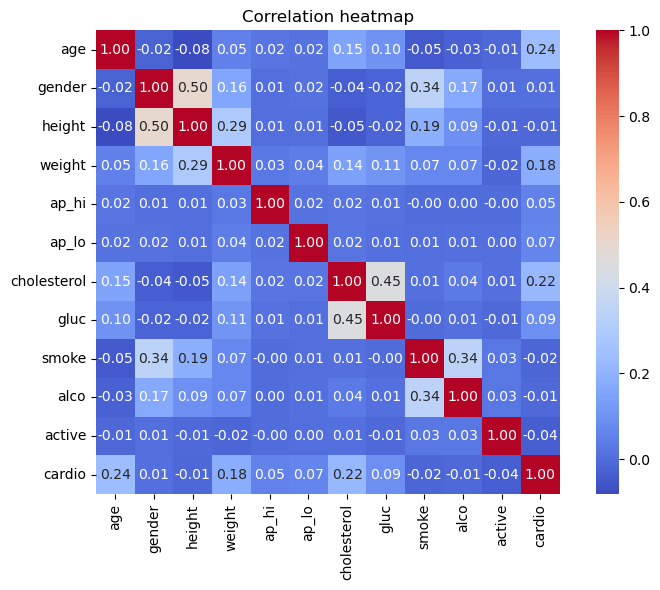

In [86]:

import seaborn as sns
plt.figure(figsize=(8, 6))  #width,height
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap")
plt.tight_layout() 
plt.show()


### Shows the correlation value numbers inside each cell.(annot = true)
###.2f decimal pleaces
# Blue = negative correlation
# Red = positive correlation
# White = near zero correlation

- ### Identify and handle outliers

### Detact Outlier

In [72]:
#Method to handle outliers: IQR,Boxplot
import seaborn as sns
numeric_value = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in numeric_value:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_limit) | (df_clean[col] > upper_limit)]
    print(f"{col} --> Outliers found: {outliers.shape[0]}")

age --> Outliers found: 4
height --> Outliers found: 519
weight --> Outliers found: 1282
ap_hi --> Outliers found: 1433
ap_lo --> Outliers found: 4617


### Remove Outlier

In [87]:
for col in numeric_value:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

In [88]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,-0.419800,2,0.443452,-0.847873,-0.122182,-0.088238,1,1,0,0,1,0
1,0.319110,1,-1.018168,0.749831,0.072610,-0.035180,3,1,0,0,1,1
2,-0.272018,1,0.078047,-0.708942,0.007679,-0.141297,3,1,0,0,0,1
3,-0.715364,2,0.565254,0.541435,0.137541,0.017879,1,1,0,0,1,1
5,1.058020,1,-1.627176,-0.500546,-0.057251,-0.088238,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,-0.124236,2,0.443452,0.124642,-0.057251,-0.088238,1,1,1,0,1,0
69996,1.205802,1,-0.774565,3.597913,0.072610,-0.035180,2,2,0,0,1,1
69997,-0.124236,2,2.270477,2.139139,0.332333,-0.035180,3,1,0,1,0,1
69998,1.205802,1,-0.165556,-0.153219,0.040145,-0.088238,1,2,0,0,0,1


###  Encode categorical variables Normalize/scale numerical features

In [73]:
# perform min-mix scaller so we can convert our data into 0 to 1 range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_value = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

df_clean[numeric_value] = scaler.fit_transform(df_clean[numeric_value])
df_clean[numeric_value]
# What to use clean or unique

C:\Users\Admin\AppData\Local\Temp\ipykernel_3568\3733434837.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[numeric_value] = scaler.fit_transform(df_clean[numeric_value])


,age,height,weight,ap_hi,ap_lo
0,0.600000,0.579487,0.273684,0.016079,0.013550
1,0.742857,0.517949,0.394737,0.017934,0.014453
2,0.628571,0.564103,0.284211,0.017316,0.012647
3,0.542857,0.584615,0.378947,0.018553,0.015357
4,0.514286,0.517949,0.242105,0.015461,0.011743
...,...,...,...,...,...
69994,0.800000,0.564103,0.368421,0.018553,0.013550
69996,0.914286,0.528205,0.610526,0.017934,0.014453
69997,0.657143,0.656410,0.500000,0.020408,0.014453
69998,0.914286,0.553846,0.326316,0.017625,0.013550


In [75]:
#convert data to mean=0 and std=1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_clean[numeric_value] = scaler.fit_transform(df_clean[numeric_value])
df_clean[numeric_value]

C:\Users\Admin\AppData\Local\Temp\ipykernel_3568\1355975204.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[numeric_value] = scaler.fit_transform(df_clean[numeric_value])


,age,height,weight,ap_hi,ap_lo
0,-0.420325,0.438964,-0.858757,-0.121991,-0.090439
1,0.314578,-1.000949,0.718685,0.068307,-0.038600
2,-0.273344,0.078985,-0.721588,0.004874,-0.142278
3,-0.714286,0.558956,0.512932,0.131739,0.013239
4,-0.861266,-1.000949,-1.270263,-0.185423,-0.194117
...,...,...,...,...,...
69994,0.608540,0.078985,0.375763,0.131739,-0.090439
69996,1.196462,-0.760963,3.530648,0.068307,-0.038600
69997,-0.126363,2.238854,2.090374,0.322036,-0.038600
69998,1.196462,-0.161000,-0.172912,0.036590,-0.090439


In [66]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['gender'] = le.fit_transform(df['gender'])

### EDA (Exploratory Data Analysis)

In [76]:
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 66792 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          66792 non-null  float64
 1   gender       66792 non-null  int64  
 2   height       66792 non-null  float64
 3   weight       66792 non-null  float64
 4   ap_hi        66792 non-null  float64
 5   ap_lo        66792 non-null  float64
 6   cholesterol  66792 non-null  int64  
 7   gluc         66792 non-null  int64  
 8   smoke        66792 non-null  int64  
 9   alco         66792 non-null  int64  
 10  active       66792 non-null  int64  
 11  cardio       66792 non-null  int64  
 12  bmi          66792 non-null  float64
dtypes: float64(6), int64(7)
memory usage: 7.1 MB


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,6.679200e+04,66792.000000,6.679200e+04,6.679200e+04,6.679200e+04,6.679200e+04,66792.000000,66792.000000,66792.000000,66792.000000,66792.000000,66792.000000,66792.000000
mean,-6.704157e-16,1.356210,1.938057e-15,-6.553095e-16,-3.839305e-16,3.476013e-17,1.382725,1.236106,0.092137,0.056294,0.798539,0.511933,27.682565
std,1.000007e+00,0.478882,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,0.690132,0.582063,0.289221,0.230491,0.401095,0.499861,6.184422
min,-3.506917e+00,1.000000,-1.312021e+01,-4.425148e+00,-1.771233e+00,-8.680243e-01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,-7.142858e-01,1.000000,-6.409706e-01,-6.530034e-01,-5.855814e-02,-9.043945e-02,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,2.061716e-02,1.000000,7.898548e-02,-1.729123e-01,-5.855814e-02,-9.043945e-02,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,26.573129
75%,7.555201e-01,2.000000,6.789489e-01,5.815165e-01,6.830663e-02,-3.860046e-02,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.468750
max,1.637404e+00,2.000000,1.027836e+01,8.605897e+00,1.007989e+02,5.651774e+01,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


### Display Graph

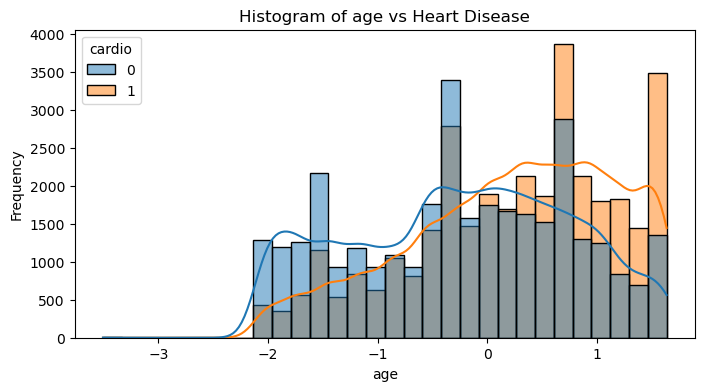

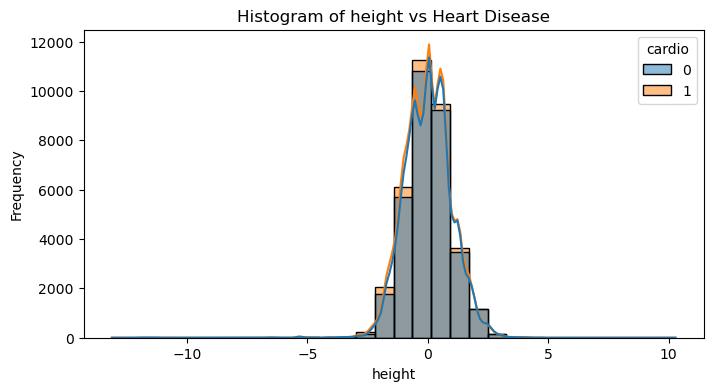

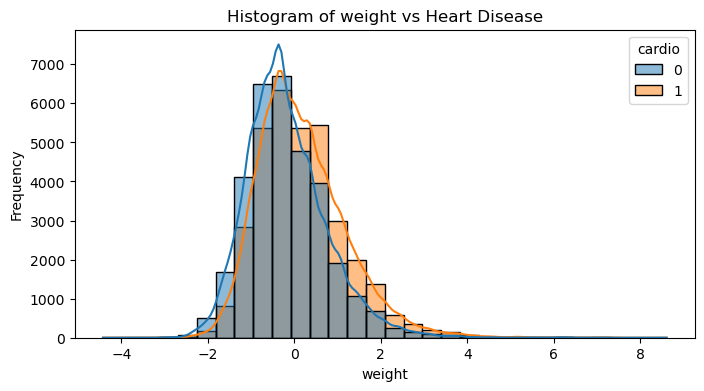

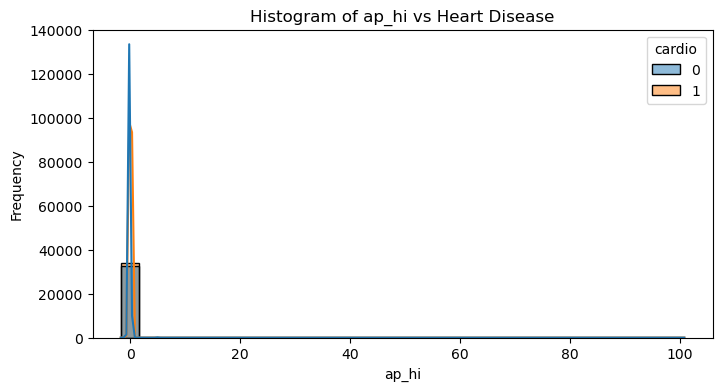

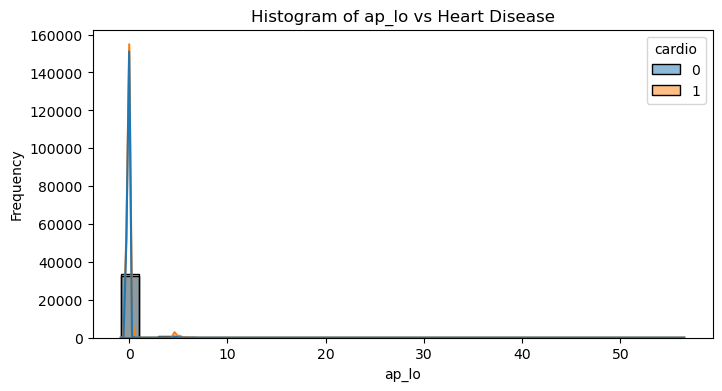

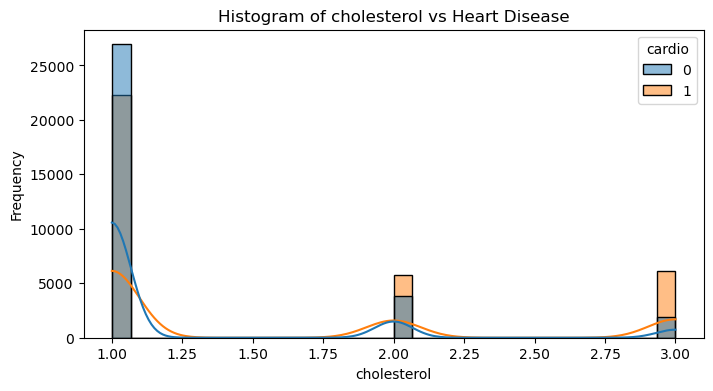

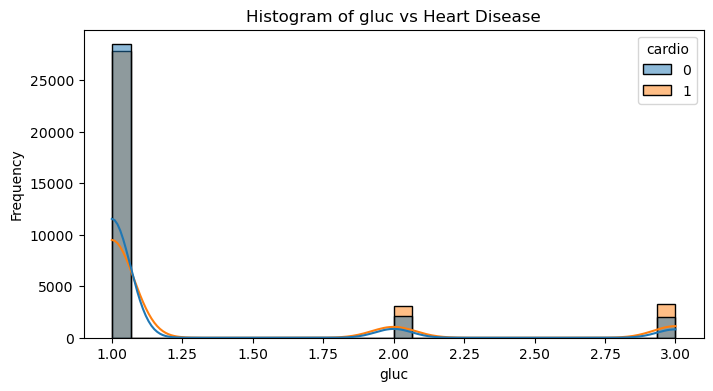

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['age','height','weight','ap_hi','ap_lo','cholesterol','gluc']

for col in features:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df_clean, x=col, hue='cardio', kde=True, bins=30) #kde use for smooth curve and hue is used for categorical column,spliting
    plt.title(f"Histogram of {col} vs Heart Disease")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [81]:
df_clean.to_csv('cardio_preprocessed.csv', index=False)

In [90]:
df_clean

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,-0.420325,2,0.438964,-0.858757,-0.121991,-0.090439,1,1,0,0,1,0,21.967120
1,0.314578,1,-1.000949,0.718685,0.068307,-0.038600,3,1,0,0,1,1,34.927679
2,-0.273344,1,0.078985,-0.721588,0.004874,-0.142278,3,1,0,0,0,1,23.507805
3,-0.714286,2,0.558956,0.512932,0.131739,0.013239,1,1,0,0,1,1,28.710479
4,-0.861266,1,-1.000949,-1.270263,-0.185423,-0.194117,1,1,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,0.608540,1,0.078985,0.375763,0.131739,-0.090439,1,1,0,0,1,1,29.384757
69996,1.196462,1,-0.760963,3.530648,0.068307,-0.038600,2,2,0,0,1,1,50.472681
69997,-0.126363,2,2.238854,2.090374,0.322036,-0.038600,3,1,0,1,0,1,31.353579
69998,1.196462,1,-0.161000,-0.172912,0.036590,-0.090439,1,2,0,0,0,1,27.099251


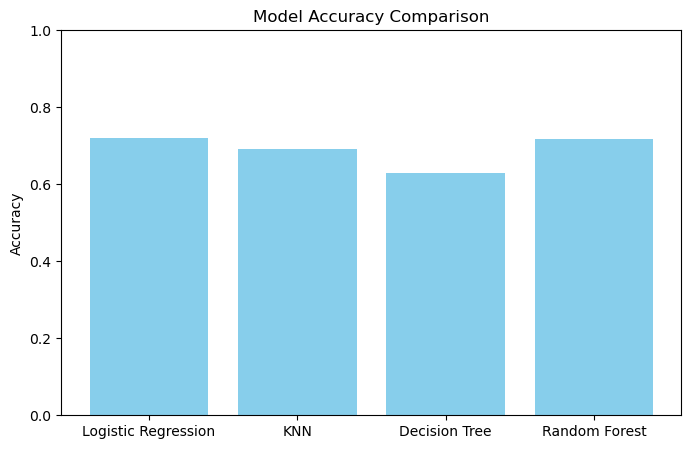

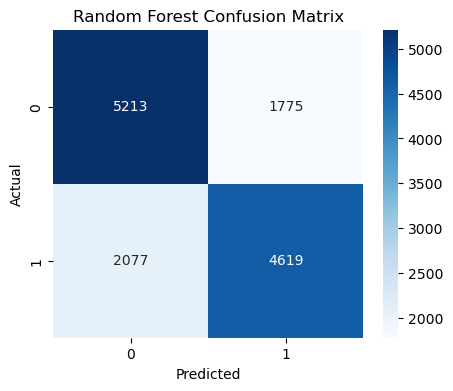

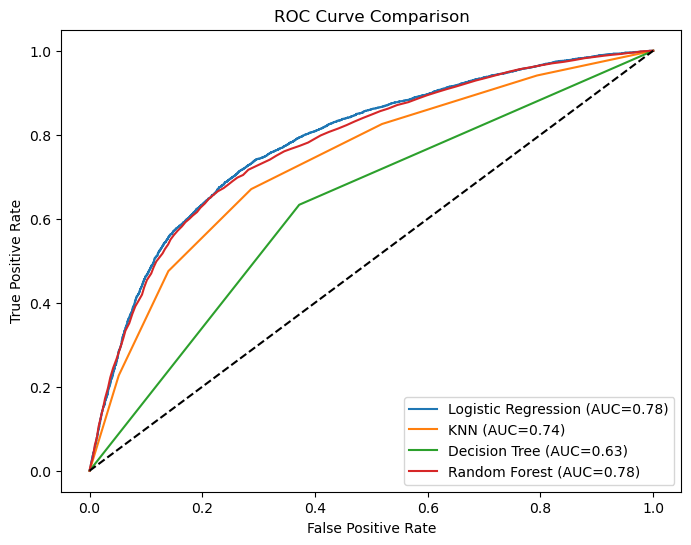

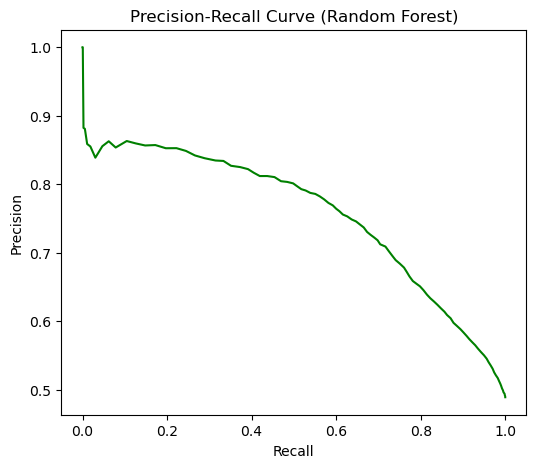

C:\Users\Admin\AppData\Local\Temp\ipykernel_25040\3354434304.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns, y=feat_imp, palette='viridis')


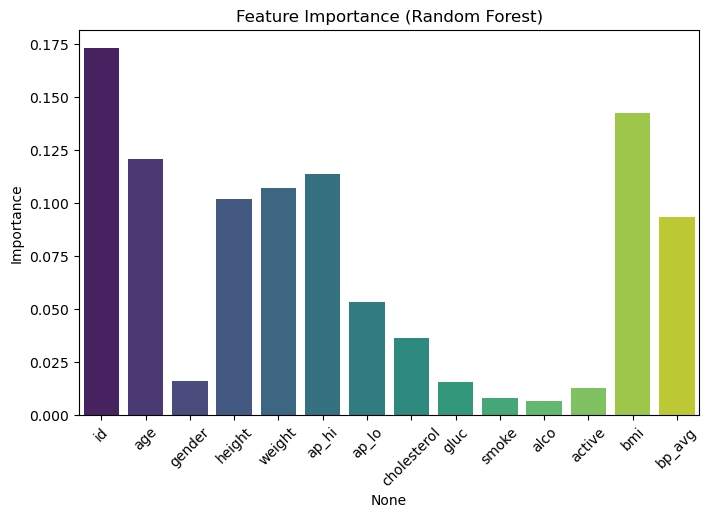

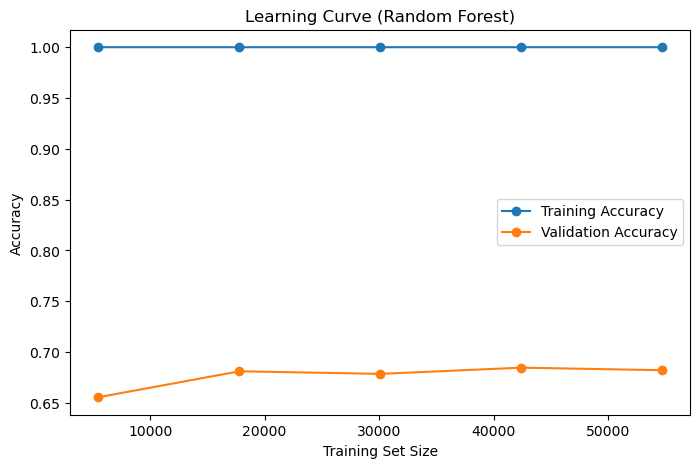

In [86]:

X = df.drop("cardio", axis=1)
y = df["cardio"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------
#  Train models
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store predictions and accuracies
accuracies = {}
y_preds = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred
    accuracies[name] = accuracy_score(y_test, y_pred)
    
    # For ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:  # Decision Tree does have predict_proba, KNN too
        y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

# ----------------------------
#  Accuracy Comparison Graph
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

# ----------------------------
#  Confusion Matrix for Random Forest
# ----------------------------
rf_cm = confusion_matrix(y_test, y_preds["Random Forest"])
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
#  ROC Curve
# ----------------------------
plt.figure(figsize=(8,6))
for name, (fpr, tpr) in roc_data.items():
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----------------------------
#  Precision-Recall Curve for Random Forest
# ----------------------------
y_prob_rf = models["Random Forest"].predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

# ----------------------------
#  Feature Importance for Random Forest
# ----------------------------
feat_imp = models["Random Forest"].feature_importances_
plt.figure(figsize=(8,5))
sns.barplot(x=X.columns, y=feat_imp, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

# ----------------------------
#  Learning Curve for Random Forest
# ----------------------------
train_sizes, train_scores, val_scores = learning_curve(
    models["Random Forest"], X_scaled, y, cv=5,
    train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy'
)
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.show()
